### Import Libraries

In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Connect to DuckDB
con = duckdb.connect('/app/analytics.duckdb', read_only=True)

### Load the dataset

In [2]:
df = con.sql("""
    SELECT * FROM mart.mart_order_items
""").df()

In [3]:
df.head(n=2)

,order_id,order_item_id,order_item_key,product_id,seller_id,shipping_limit_date_et,price,freight_value,total_item_value,freight_pct_of_price,customer_unique_id,order_status,is_delivered,is_in_progress,is_canceled,order_purchase_timestamp_et,order_delivered_customer_date_et,order_estimated_delivery_date_et,is_delivered_on_time,days_to_delivery,delivery_speed_category,customer_city,customer_state,customer_state_name,customer_region,review_score,review_sentiment,has_review,days_to_review,is_quick_review,is_payment_details_missing,total_payment_value,total_payment_installments,first_payment_type,primary_payment_type,primary_payment_category,revenue_delivered,product_price_delivered,freight_delivered,product_name_length,product_description_length,product_category_name,product_category_name_english,broad_category,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_volume_cm3,volumetric_weight_kg,chargeable_weight_kg,freight_per_kg,product_size_category,is_heavy_item,is_high_value_item,has_photos,has_detailed_description,seller_city,seller_state,seller_zip_code_prefix,seller_geolocation_latitude,seller_geolocation_longitude,seller_state_name,seller_region,customer_zip_code_prefix,customer_geolocation_latitude,customer_geolocation_longitude,customer_total_orders,customer_total_delivered_orders,customer_in_progress_orders,customer_canceled_orders,customer_cancellation_rate,customer_has_repeat_orders,customer_lifetime_value,customer_first_order_date,customer_last_order_date,customer_lifetime_days,customer_avg_days_between_orders,customer_pct_orders_paid_with_voucher,customer_pct_orders_paid_with_credit_card,customer_dominant_payment_type,customer_avg_review_score,customer_reviewed_orders,customer_review_rate,seller_total_orders,seller_total_delivered_orders,seller_has_repeat_orders,seller_in_progress_orders,seller_canceled_orders,seller_cancellation_rate,seller_total_items_sold,seller_unique_products_sold,seller_unique_categories_sold,seller_avg_item_price,seller_avg_freight_per_item,seller_total_product_revenue,seller_total_freight_collected,seller_total_order_value,seller_lifetime_value,seller_avg_delivery_days,seller_on_time_delivery_rate,seller_avg_review_score,seller_reviewed_orders,seller_positive_review_rate,seller_first_sale_date,seller_last_sale_date,seller_tenure_days,product_broad_category,product_total_orders,product_total_units_sold,product_total_revenue,product_total_freight,product_total_value,product_avg_price,product_avg_freight,product_avg_review_score,product_reviewed_orders,product_positive_review_rate,product_avg_delivery_days,product_unique_sellers,product_first_sale_date,product_last_sale_date
0,00010242fe8c5a6d1ba2dd792cb16214,1,ad13fa52510f27a832d8059433055035,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 08:45:35,58.90,13.29,72.19,0.23,871766c5855e863f6eccc05f988b23cb,delivered,True,False,False,2017-09-13 07:59:02,2017-09-20 22:43:48,2017-09-28 23:00:00,True,7,fast,campos dos goytacazes,RJ,Rio de Janeiro,Southeast,5,positive,True,0,True,False,72.19,2.00,credit_card,credit_card,card,72.19,58.90,13.29,58,598,cool_stuff,cool_stuff,"Sports, Leisure & Toys",650,28,9,14,3528,0.59,0.65,20.45,medium,False,False,True,True,volta redonda,SP,27277,-22.50,-44.12,Rio de Janeiro,Southeast,28013,-21.76,-41.30,1,1,0,0,0.00,False,72.19,2017-09-13 07:59:02,2017-09-13 07:59:02,0,NaN,0.00,1.00,credit_card,5.00,1,1.00,138,134,True,4,0,0.00,147,23,2,80.42,19.33,11821.11,2840.90,14662.01,17508.62,14.07,1.02,4.05,151,0.75,2017-03-15 08:19:06,2018-08-18 20:19:10,521,"Sports, Leisure & Toys",9,9,533.10,198.30,731.40,59.23,22.03,4.44,9,0.89,15.11,1,2017-06-05 11:22:19,2018-05-18 09:25:53
1,00042b26cf59d7ce69dfabb4e55b4fd9,1,cbcfdbd69c07fac708969664b969ab25,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 10:57:51,199.90,18.14,218.04,0.09,64b576fb70d441e8f1b2d7d446e483c5,delivered,True,False,False,2017-02-04 10:57:51,2017-03-01 14:42:31,2017-03-16 23:00:00

#### Overview

In [4]:
print(f"DATASET OVERVIEW")
print(f"{'='*40}")
print(f"Total revenue:         R$ {df['total_item_value'].sum():,.2f}")
print(f"Unique orders:         {df['order_id'].nunique():,}")
print(f"Unique customers:      {df['customer_unique_id'].nunique():,}")
print(f"Unique sellers:        {df['seller_id'].nunique():,}")
print(f"Unique products:       {df['product_id'].nunique():,}")
print(f"Delivered order items: {len(df):,}")
print(f"Date range:            {df['order_purchase_timestamp_et'].min().date()} to {df['order_purchase_timestamp_et'].max().date()}")

DATASET OVERVIEW
Total revenue:         R$ 15,843,553.24
Unique orders:         98,666
Unique customers:      95,420
Unique sellers:        3,095
Unique products:       32,951
Delivered order items: 112,650
Date range:            2016-09-04 to 2018-09-03


##### Filter for only delivered orders

In [5]:
df_delivered = df[df['is_delivered']==True]

In [6]:
print(f"DELIVERED DATASET OVERVIEW")
print(f"{'='*40}")
print(f"Total revenue:         R$ {df_delivered['total_item_value'].sum():,.2f}")
print(f"Unique orders:         {df_delivered['order_id'].nunique():,}")
print(f"Unique customers:      {df_delivered['customer_unique_id'].nunique():,}")
print(f"Unique sellers:        {df_delivered['seller_id'].nunique():,}")
print(f"Unique products:       {df_delivered['product_id'].nunique():,}")
print(f"Delivered order items: {len(df_delivered):,}")
print(f"Date range:            {df_delivered['order_purchase_timestamp_et'].min().date()} to {df_delivered['order_purchase_timestamp_et'].max().date()}")

DELIVERED DATASET OVERVIEW
Total revenue:         R$ 15,418,394.83
Unique orders:         96,470
Unique customers:      93,350
Unique sellers:        2,970
Unique products:       32,214
Delivered order items: 110,189
Date range:            2016-09-15 to 2018-08-29


#### Monthly Trends (Delivered Orders)

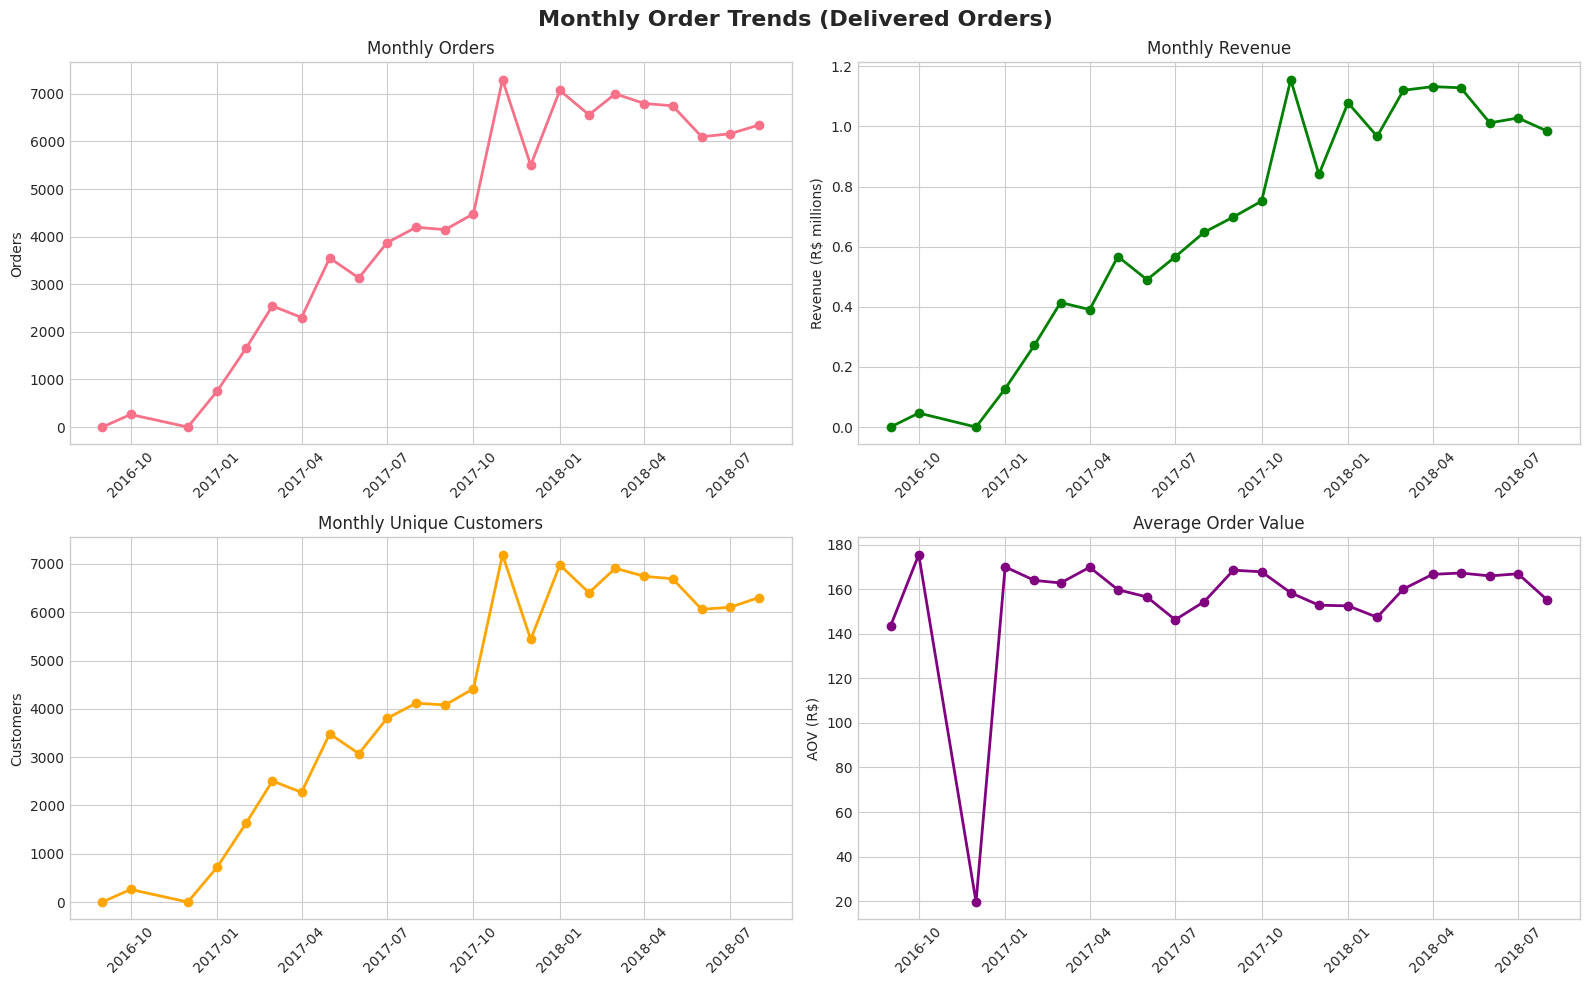

In [7]:
# Monthly order trends
## Revenue, 
monthly = df_delivered.groupby(df_delivered['order_purchase_timestamp_et'].dt.to_period('M')).agg(
    revenue=('revenue_delivered', 'sum'),
    orders=('order_id', 'nunique'),
    customers=('customer_unique_id', 'nunique')
).reset_index()
monthly['avg_order_value'] = monthly['revenue'] / monthly['orders']

monthly['order_purchase_timestamp_et'] = monthly['order_purchase_timestamp_et'].dt.to_timestamp()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Monthly Order Trends (Delivered Orders)', fontsize=16, fontweight='bold')

# Orders
axes[0,0].plot(monthly['order_purchase_timestamp_et'], monthly['orders'], marker='o', linewidth=2)
axes[0,0].set_title('Monthly Orders')
axes[0,0].set_ylabel('Orders')
axes[0,0].tick_params(axis='x', rotation=45)

# Revenue
axes[0,1].plot(monthly['order_purchase_timestamp_et'], monthly['revenue'] / 1e6, marker='o', linewidth=2, color='green')
axes[0,1].set_title('Monthly Revenue')
axes[0,1].set_ylabel('Revenue (R$ millions)')
axes[0,1].tick_params(axis='x', rotation=45)

# Unique Customers
axes[1,0].plot(monthly['order_purchase_timestamp_et'], monthly['customers'], marker='o', linewidth=2, color='orange')
axes[1,0].set_title('Monthly Unique Customers')
axes[1,0].set_ylabel('Customers')
axes[1,0].tick_params(axis='x', rotation=45)

# AOV
axes[1,1].plot(monthly['order_purchase_timestamp_et'], monthly['avg_order_value'], marker='o', linewidth=2, color='purple')
axes[1,1].set_title('Average Order Value')
axes[1,1].set_ylabel('AOV (R$)')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('/app/outputs/01_monthly_trends.png', dpi=150, bbox_inches='tight')
plt.show()

#### Geographic distribution (Delivered Orders) -- Customer Region

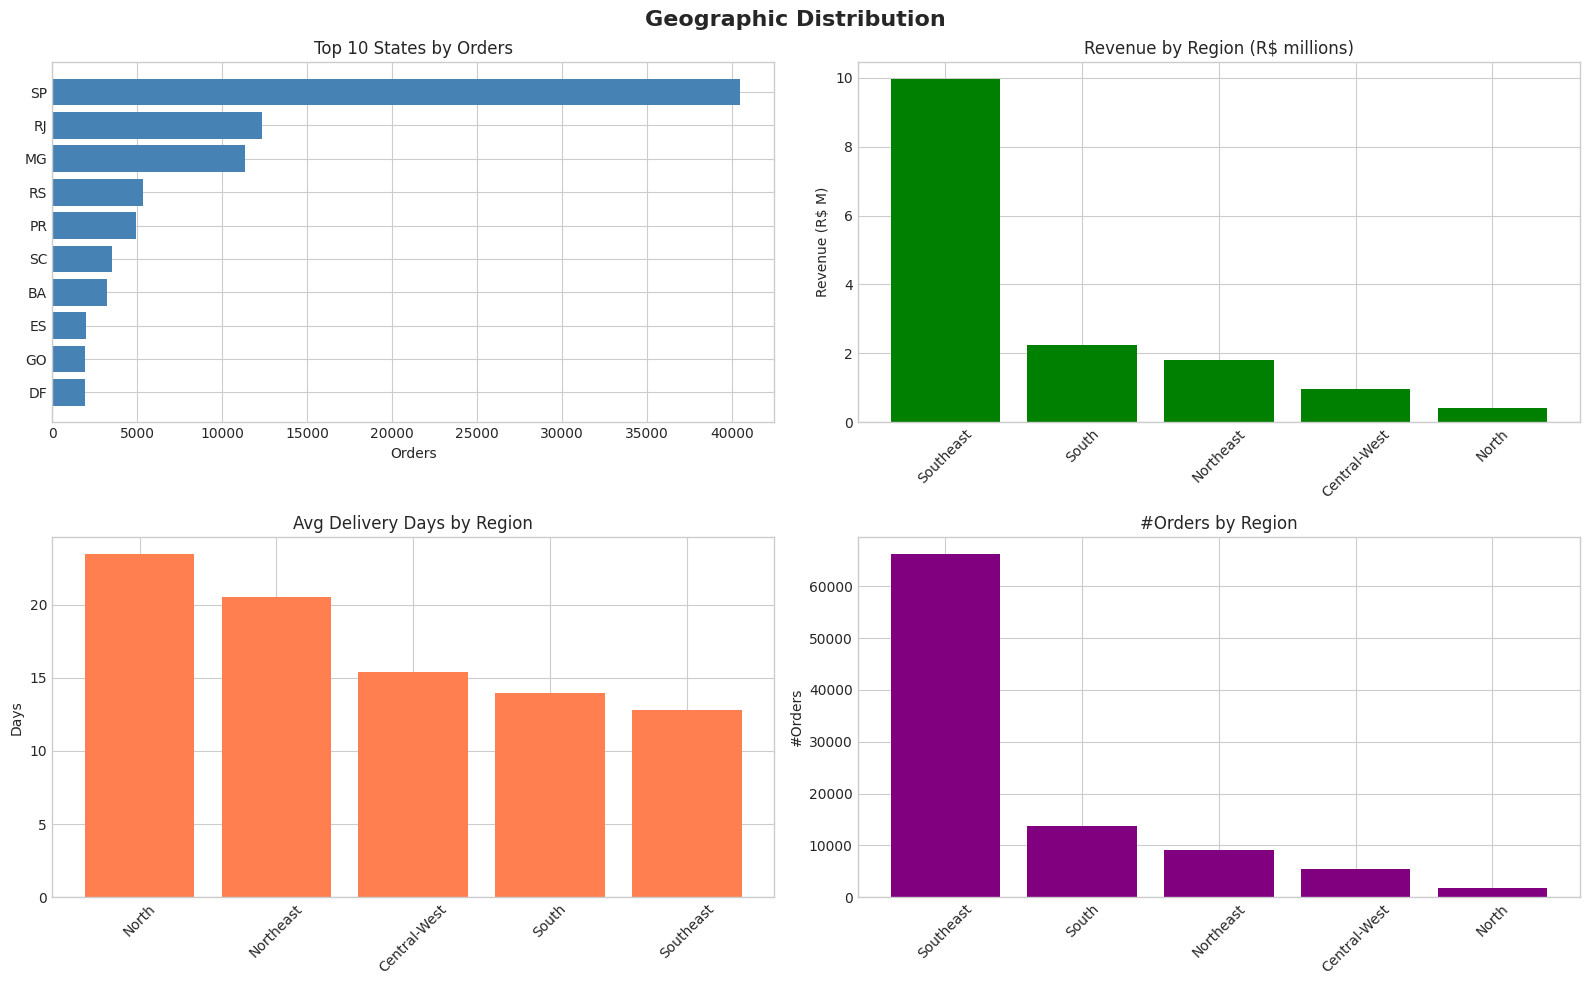

In [8]:
geo = df_delivered.groupby(['customer_state', 'customer_state_name', 'customer_region']).agg(
    orders=('order_id', 'nunique'),
    revenue=('revenue_delivered', 'sum'),
    avg_delivery_days=('days_to_delivery', 'mean')
).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Geographic Distribution', fontsize=16, fontweight='bold')

# Top 10
top10 = geo.sort_values('orders', ascending=False).head(10)
axes[0,0].barh(top10['customer_state'], top10['orders'], color='steelblue')
axes[0,0].set_title('Top 10 States by Orders')
axes[0,0].set_xlabel('Orders')
axes[0,0].invert_yaxis()

# Revenue by Region
region = geo.groupby('customer_region').agg({'revenue': 'sum'}).sort_values('revenue', ascending=False).reset_index()
axes[0,1].bar(region['customer_region'], region['revenue'] / 1e6, color='green')
axes[0,1].set_title('Revenue by Region (R$ millions)')
axes[0,1].set_ylabel('Revenue (R$ M)')
axes[0,1].tick_params(axis='x', rotation=45)

# Avg Delivery Days by Region
region_del = geo.groupby('customer_region')['avg_delivery_days'].mean().sort_values(ascending=False).reset_index()
axes[1,0].bar(region_del['customer_region'], region_del['avg_delivery_days'], color='coral')
axes[1,0].set_title('Avg Delivery Days by Region')
axes[1,0].set_ylabel('Days')
axes[1,0].tick_params(axis='x', rotation=45)

# Orders by Region
region_orders = geo.groupby('customer_region')['orders'].sum().sort_values(ascending=False).reset_index()
axes[1,1].bar(region_orders['customer_region'], region_orders['orders'], color='purple')
axes[1,1].set_title('#Orders by Region')
axes[1,1].set_ylabel('#Orders')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('/app/outputs/02_geographic_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

#### Delivery Performance

In [9]:
# Days late
df_delivered['days_late'] = (df_delivered['order_delivered_customer_date_et'] - df_delivered['order_estimated_delivery_date_et']).dt.total_seconds() / 86400

print(f"DELIVERY PERFORMANCE")
print(f"{'='*40}")
print(f"On-time rate: {df_delivered['is_delivered_on_time'].mean():.1%}")
print(f"\nDelivery speed breakdown:")
print(df_delivered['delivery_speed_category'].value_counts(normalize=True).round(3))
print(f"\nDelivery days stats:")
print(df_delivered['days_to_delivery'].describe().round(1))

DELIVERY PERFORMANCE
On-time rate: 92.1%

Delivery speed breakdown:
delivery_speed_category
standard    0.40
fast        0.25
slow        0.24
express     0.07
very_slow   0.04
Name: proportion, dtype: float64

Delivery days stats:
count   110189.00
mean        12.40
std          9.50
min          0.00
25%          7.00
50%         10.00
75%         15.00
max        210.00
Name: days_to_delivery, dtype: Float64


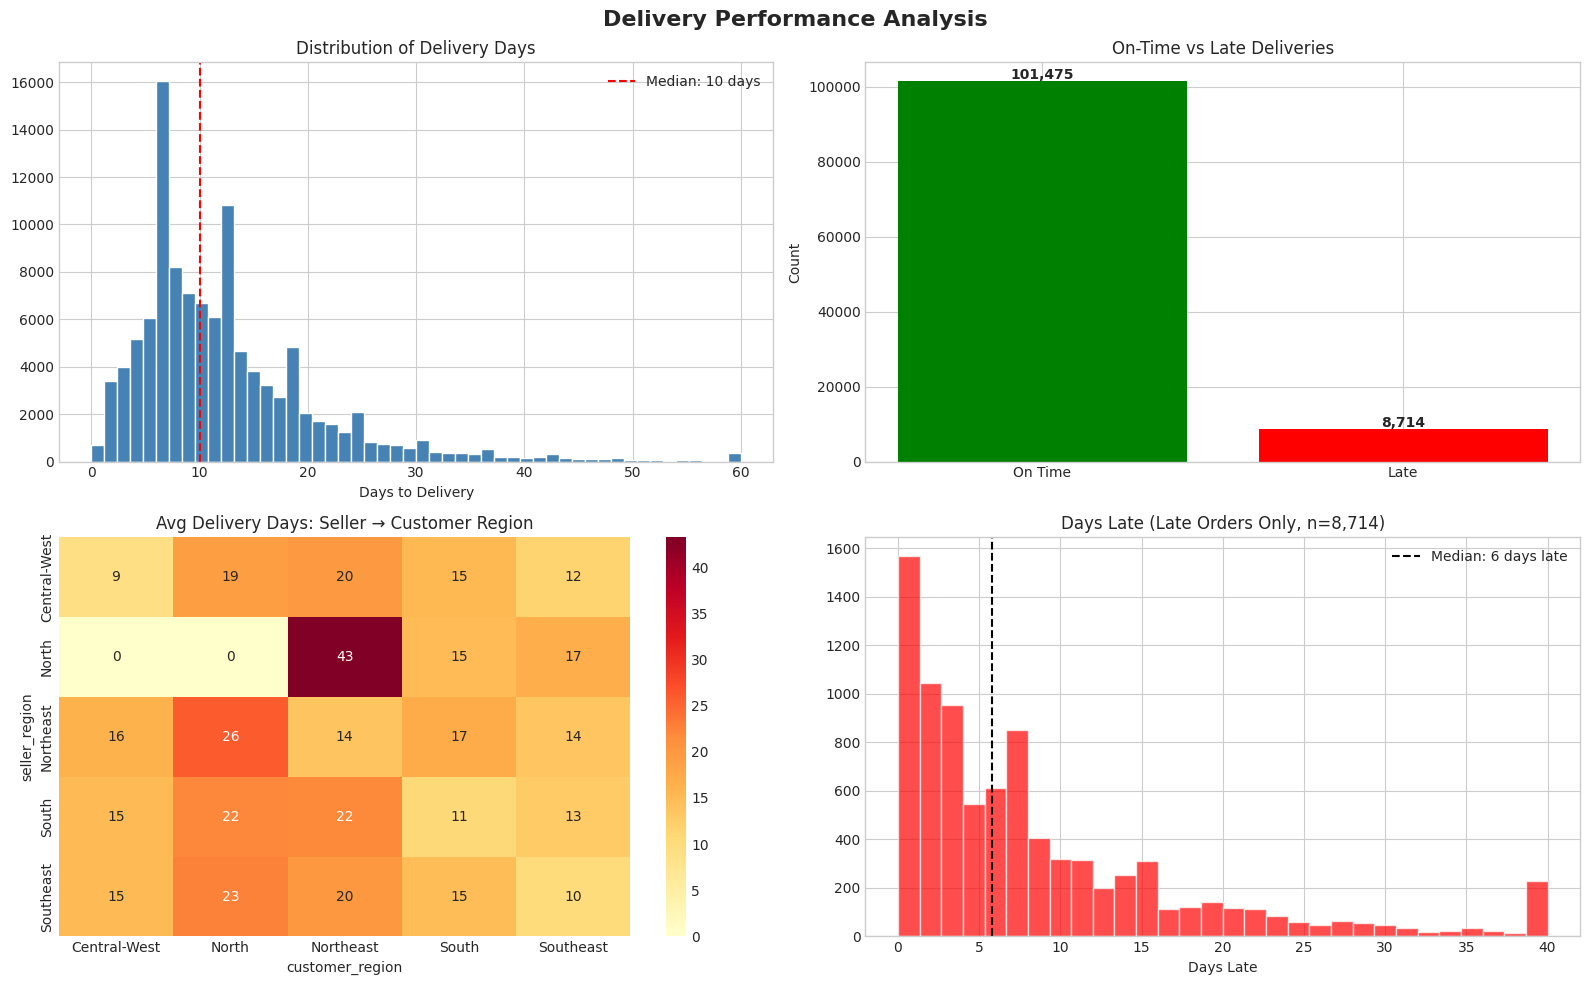

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Delivery Performance Analysis', fontsize=16, fontweight='bold')

# Distribution of delivery days
axes[0,0].hist(df_delivered['days_to_delivery'].clip(upper=60), bins=50, color='steelblue', edgecolor='white')
axes[0,0].axvline(df_delivered['days_to_delivery'].median(), color='red', linestyle='--', 
                   label=f"Median: {df_delivered['days_to_delivery'].median():.0f} days")
axes[0,0].set_title('Distribution of Delivery Days')
axes[0,0].set_xlabel('Days to Delivery')
axes[0,0].legend()

# On-time vs Late
late_counts = df_delivered['is_delivered_on_time'].value_counts()
axes[0,1].bar(['On Time', 'Late'], [late_counts.get(True, 0), late_counts.get(False, 0)], 
              color=['green', 'red'])
axes[0,1].set_title('On-Time vs Late Deliveries')
axes[0,1].set_ylabel('Count')
for i, v in enumerate([late_counts.get(True, 0), late_counts.get(False, 0)]):
    axes[0,1].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

# Heatmap: Seller region → Customer region delivery days
cross = df_delivered.groupby(['seller_region', 'customer_region'])['days_to_delivery'].mean()
pivot = cross.unstack(level='customer_region').fillna(0).astype(float)
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', ax=axes[1,0])
axes[1,0].set_title('Avg Delivery Days: Seller → Customer Region')

# Days late distribution (late orders only)
late_only = df_delivered[df_delivered['days_late'] > 0]['days_late']
axes[1,1].hist(late_only.clip(upper=40), bins=30, color='red', edgecolor='white', alpha=0.7)
axes[1,1].axvline(late_only.median(), color='black', linestyle='--',
                   label=f"Median: {late_only.median():.0f} days late")
axes[1,1].set_title(f'Days Late (Late Orders Only, n={len(late_only):,})')
axes[1,1].set_xlabel('Days Late')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('/app/outputs/03_delivery_performance.png', dpi=150, bbox_inches='tight')
plt.show()

#### Seller Overview (Delivered Orders)

In [11]:
sellers = df_delivered.groupby('seller_id').agg(
    total_orders=('order_id', 'nunique'),
    total_items=('order_item_id', 'count'),
    total_revenue=('revenue_delivered', 'sum'),
    avg_price=('price', 'mean'),
    unique_products=('product_id', 'nunique'),
    unique_categories=('broad_category', 'nunique'),
    seller_region=('seller_region', 'first'),
    seller_state=('seller_state', 'first')
).reset_index()

# Order-level aggregations (deduplicate first)
order_seller = df_delivered.drop_duplicates(subset=['order_id', 'seller_id'])
order_level = order_seller.groupby('seller_id').agg(
    avg_review_score=('review_score', 'mean'),
    avg_delivery_days=('days_to_delivery', 'mean'),
    on_time_rate=('is_delivered_on_time', 'mean')
).reset_index()

# Merge
sellers = sellers.merge(order_level, on='seller_id', how='left')

print(f"SELLER OVERVIEW")
print(f"{'='*40}")
print(f"Total sellers: {len(sellers):,}")
print(f"\nOrders per seller:")
print(sellers['total_orders'].describe().round(1))
print(f"\nSellers with only 1 order: {(sellers['total_orders'] == 1).sum()} ({(sellers['total_orders'] == 1).mean():.1%})")
print(f"Sellers with 100+ orders: {(sellers['total_orders'] >= 100).sum()} ({(sellers['total_orders'] >= 100).mean():.1%})")

SELLER OVERVIEW
Total sellers: 2,970

Orders per seller:
count   2970.00
mean      32.90
std      105.40
min        1.00
25%        2.00
50%        7.00
75%       22.00
max     1819.00
Name: total_orders, dtype: float64

Sellers with only 1 order: 536 (18.0%)
Sellers with 100+ orders: 210 (7.1%)


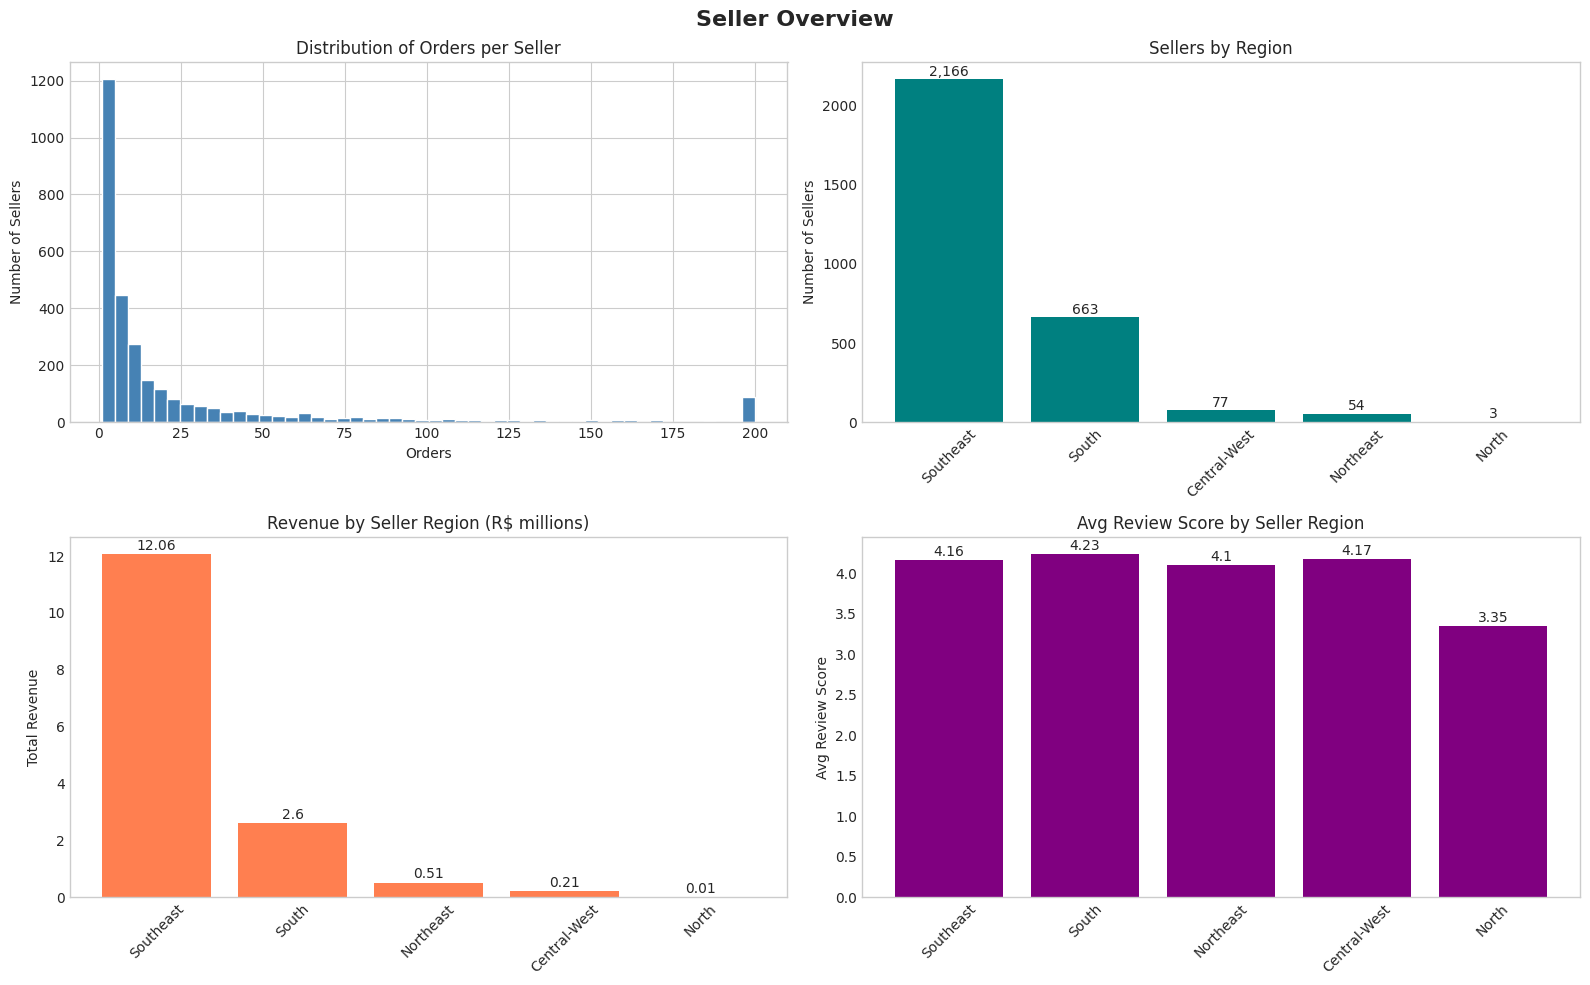

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Seller Overview', fontsize=16, fontweight='bold')

# Orders per seller (Clipped at 200)
axes[0,0].hist(sellers['total_orders'].clip(upper=200), bins=50, color='steelblue', edgecolor='white')
axes[0,0].set_title('Distribution of Orders per Seller')
axes[0,0].set_xlabel('Orders')
axes[0,0].set_ylabel('Number of Sellers')

# Sellers by region
seller_region = sellers.groupby('seller_region').size().sort_values(ascending=False).reset_index(name='count')
axes[0,1].bar(seller_region['seller_region'], seller_region['count'], color='teal')
axes[0,1].set_title('Sellers by Region')
axes[0,1].set_ylabel('Number of Sellers')
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].grid(False)
for i, v in enumerate(seller_region['count']):
    axes[0,1].text(i, v+20, f'{v:,}', ha='center')

seller_revenue = sellers.groupby('seller_region').agg({'total_revenue': 'sum'}).sort_values('total_revenue', ascending=False).reset_index()
seller_revenue['total_revenue'] = (seller_revenue['total_revenue'] / 1_000_000).round(2)
axes[1,0].bar(seller_revenue['seller_region'], seller_revenue['total_revenue'], color='coral')
axes[1,0].set_title('Revenue by Seller Region (R$ millions)')
axes[1,0].set_ylabel('Total Revenue')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].grid(False)
for i, v in enumerate(seller_revenue['total_revenue']):
    axes[1,0].text(i, v+0.15, f'{v:,}', ha='center')

seller_review_score = sellers.groupby('seller_region').agg({'total_revenue': 'sum','avg_review_score': 'mean'}).sort_values('total_revenue', ascending=False).reset_index()
seller_review_score['avg_review_score'] = seller_review_score['avg_review_score'].round(2)
axes[1,1].bar(seller_review_score['seller_region'], seller_review_score['avg_review_score'], color='purple')
axes[1,1].set_title('Avg Review Score by Seller Region')
axes[1,1].set_ylabel('Avg Review Score')
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].grid(False)
for i, v in enumerate(seller_review_score['avg_review_score']):
    axes[1,1].text(i, v+0.05, f'{v:,}', ha='center')    

plt.tight_layout()
plt.savefig('/app/outputs/04_seller_overview.png', dpi=150, bbox_inches='tight')
plt.show()

#### Seller Performance (Deep-Dive)

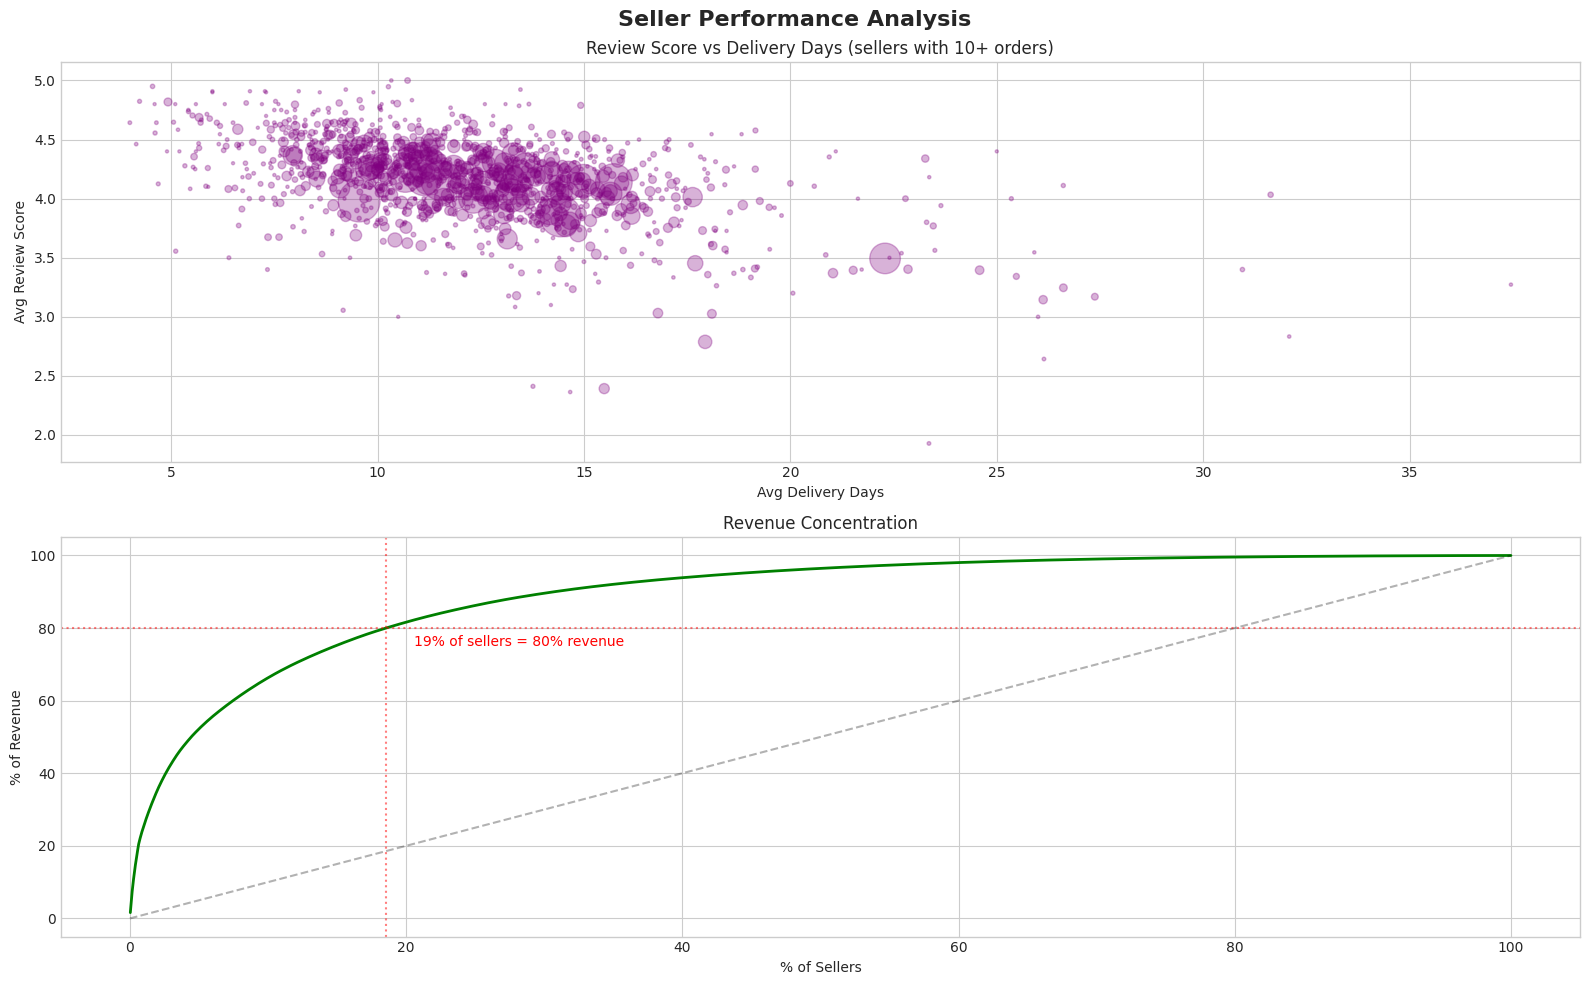

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle('Seller Performance Analysis', fontsize=16, fontweight='bold')

# Avg review score vs avg delivery days (per seller, with atleast 10 orders)
active = sellers[sellers['total_orders'] >= 10]
scatter = axes[0].scatter(active['avg_delivery_days'], active['avg_review_score'], 
                            alpha=0.3, s=active['total_orders'] * 0.5, color='purple')
axes[0].set_title('Review Score vs Delivery Days (sellers with 10+ orders)')
axes[0].set_xlabel('Avg Delivery Days')
axes[0].set_ylabel('Avg Review Score')

# Revenue concentration (starting with top sellers by revenue)
sellers_sorted = sellers.sort_values('total_revenue', ascending=False).reset_index(drop=True)
sellers_sorted['cumulative_revenue_pct'] = sellers_sorted['total_revenue'].cumsum() / sellers_sorted['total_revenue'].sum()
sellers_sorted['seller_pct'] = (sellers_sorted.index + 1) / len(sellers_sorted)
axes[1].plot(sellers_sorted['seller_pct'] * 100, sellers_sorted['cumulative_revenue_pct'] * 100, linewidth=2, color='green')
axes[1].plot([0, 100], [0, 100], 'k--', alpha=0.3)
axes[1].set_title('Revenue Concentration')
axes[1].set_xlabel('% of Sellers')
axes[1].set_ylabel('% of Revenue')

# Find the 80/20 point
pct_80 = sellers_sorted[sellers_sorted['cumulative_revenue_pct'] >= 0.80].iloc[0]['seller_pct']
axes[1].axhline(y=80, color='red', linestyle=':', alpha=0.5)
axes[1].axvline(x=pct_80 * 100, color='red', linestyle=':', alpha=0.5)
axes[1].text(pct_80 * 100 + 2, 75, f'{pct_80:.0%} of sellers = 80% revenue', color='red')

plt.tight_layout()
plt.savefig('/app/outputs/05_seller_performance.png', dpi=150, bbox_inches='tight')
plt.show()

#### Category Overview (Delivered Orders)

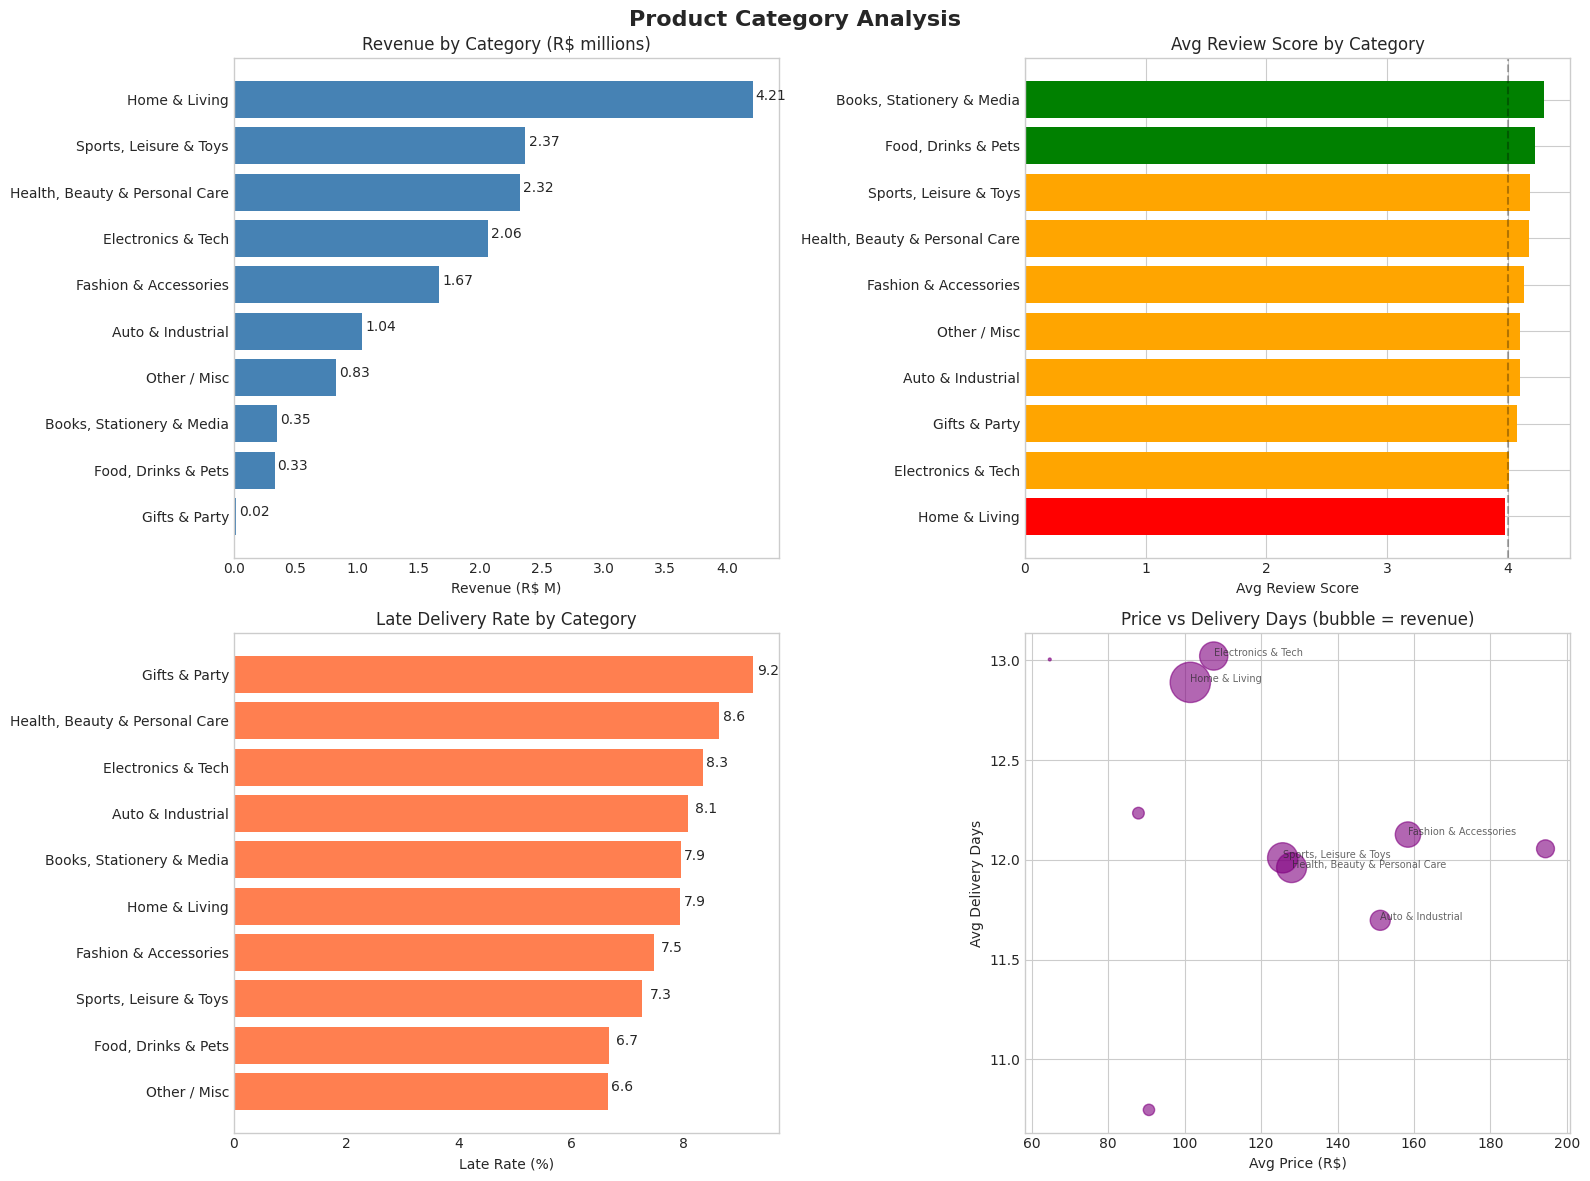

In [14]:
category = df_delivered.groupby('broad_category').agg(
    orders=('order_id', 'nunique'),
    items=('order_item_id', 'count'),
    revenue=('revenue_delivered', 'sum'),
    avg_price=('price', 'mean'),
    avg_review=('review_score', 'mean'),
    avg_delivery_days=('days_to_delivery', 'mean'),
    late_rate=('is_delivered_on_time', lambda x: 1 - x.mean())
).reset_index().sort_values('revenue', ascending=False)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Product Category Analysis', fontsize=16, fontweight='bold')

# Revenue by category
axes[0,0].barh(category['broad_category'], category['revenue'] / 1_000_000, color='steelblue')
axes[0,0].set_title('Revenue by Category (R$ millions)')
axes[0,0].set_xlabel('Revenue (R$ M)')
axes[0,0].invert_yaxis()
axes[0,0].grid(False)
for i, v in enumerate((category['revenue']/ 1_000_000).round(2)):
    axes[0,0].text(v+0.15, i, f'{v:,}', ha='center')  

# Avg review by category
cat_sorted = category.sort_values('avg_review', ascending=True)
colors = ['red' if x < 4 else 'orange' if x < 4.2 else 'green' for x in cat_sorted['avg_review']]
axes[0,1].barh(cat_sorted['broad_category'], cat_sorted['avg_review'], color=colors)
axes[0,1].set_title('Avg Review Score by Category')
axes[0,1].set_xlabel('Avg Review Score')
axes[0,1].axvline(x=4, color='black', linestyle='--', alpha=0.3)

# Late delivery rate by category
cat_late = category.sort_values('late_rate', ascending=False)
axes[1,0].barh(cat_late['broad_category'], cat_late['late_rate'] * 100, color='coral')
axes[1,0].set_title('Late Delivery Rate by Category')
axes[1,0].set_xlabel('Late Rate (%)')
axes[1,0].invert_yaxis()
axes[1,0].grid(False)
for i, v in enumerate((cat_late['late_rate']*100).round(1)):
    axes[1,0].text(v+0.3, i, f'{v:,}', ha='center') 

# Avg price vs avg delivery days (bubble = revenue)
scatter = axes[1,1].scatter(category['avg_price'], category['avg_delivery_days'],
                            s=category['revenue'] / 5000, alpha=0.6, color='purple')
for _, row in category.iterrows():
    if row['revenue'] > 1_000_000:
        axes[1,1].annotate(row['broad_category'], (row['avg_price'], row['avg_delivery_days']),
                          fontsize=7, alpha=0.7)
axes[1,1].set_title('Price vs Delivery Days (bubble = revenue)')
axes[1,1].set_xlabel('Avg Price (R$)')
axes[1,1].set_ylabel('Avg Delivery Days')

plt.tight_layout()
plt.savefig('/app/outputs/06_category_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

#### Payment Analysis

In [15]:
print(f"PAYMENT ANALYSIS")
print(f"{'='*40}")
order_payment = df_delivered.groupby('primary_payment_type')['order_id'].nunique()
print(order_payment.sort_values(ascending=False))
customer_payment = df_delivered.groupby('customer_dominant_payment_type')['customer_unique_id'].nunique()
print("\n")
print(customer_payment.sort_values(ascending=False))

PAYMENT ANALYSIS
primary_payment_type
credit_card    72778
boleto         19191
voucher         3017
debit_card      1483
Name: order_id, dtype: int64


customer_dominant_payment_type
credit_card    70421
boleto         18587
voucher         2898
debit_card      1442
not_defined        1
Name: customer_unique_id, dtype: int64


### Findings Summary

In [16]:
print(f"OTHER SUMMARY STATS")
print(f"{'='*70}")
print(f"São Paulo Order%:                        {geo[geo['customer_state']=='SP']['orders'].iloc[0]/geo['orders'].sum():.0%}")
print(f"Souteast Region Order%:                  {region_orders[region_orders['customer_region']=='Southeast']['orders'].iloc[0]/region_orders['orders'].sum():.0%}")
print(f"North Region Delivery Time over Others:  {region_del[region_del['customer_region']=='North']['avg_delivery_days'].mean()/region_del[region_del['customer_region']!='North']['avg_delivery_days'].mean():.1f}")

OTHER SUMMARY STATS
São Paulo Order%:                        42%
Souteast Region Order%:                  69%
North Region Delivery Time over Others:  1.5


##### Summary

1. **GROWTH**: Strong growth from late 2016 to Nov 2017, then plateaued at ~7K orders/month.
   AOV stable around R$160.

2. **GEOGRAPHY**: São Paulo dominates (40%+ of orders). Southeast = 69% of orders.
   Most sellers also in Southeast. North region averages 1.5x longer delivery times compared to the average of all other regions.

3. **DELIVERY**: 92.1% on-time rate. Median delivery = 10 days.
   Cross-region shipments (especially involving North) take significantly longer.
   Seller-to-customer distance is a key delivery driver.

4. **SELLERS**: Highly concentrated — 19% of sellers drive 80% of revenue.
   Median seller has only 7 orders. 18% have just 1 order.
   Clear negative correlation between delivery time and review scores.

5. **CATEGORIES**: Home & Living = top revenue but lowest review scores.
   Gifts & Party = highest late rate. Books & Food = best reviewed, lower late rates.
   Heavier/pricier categories have longer delivery times.

6. **CUSTOMERS**: 97% are one-time buyers. Very low repeat purchase behavior.

**IMPLICATIONS FOR ML:**
- Seller Segmentation: Rich variation in seller performance, volume, and quality.
   Focus on orders, revenue, delivery performance, reviews, and category diversity.
- Delivery Delay Prediction: Geography (seller/customer regions), product weight/size,
   category, and seller track record are likely strong predictors.
